Nodes: 95
Edges: 69


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2366 (\N{DEVANAGARI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2342 (\N{DEVANAGARI LETTER DA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/li

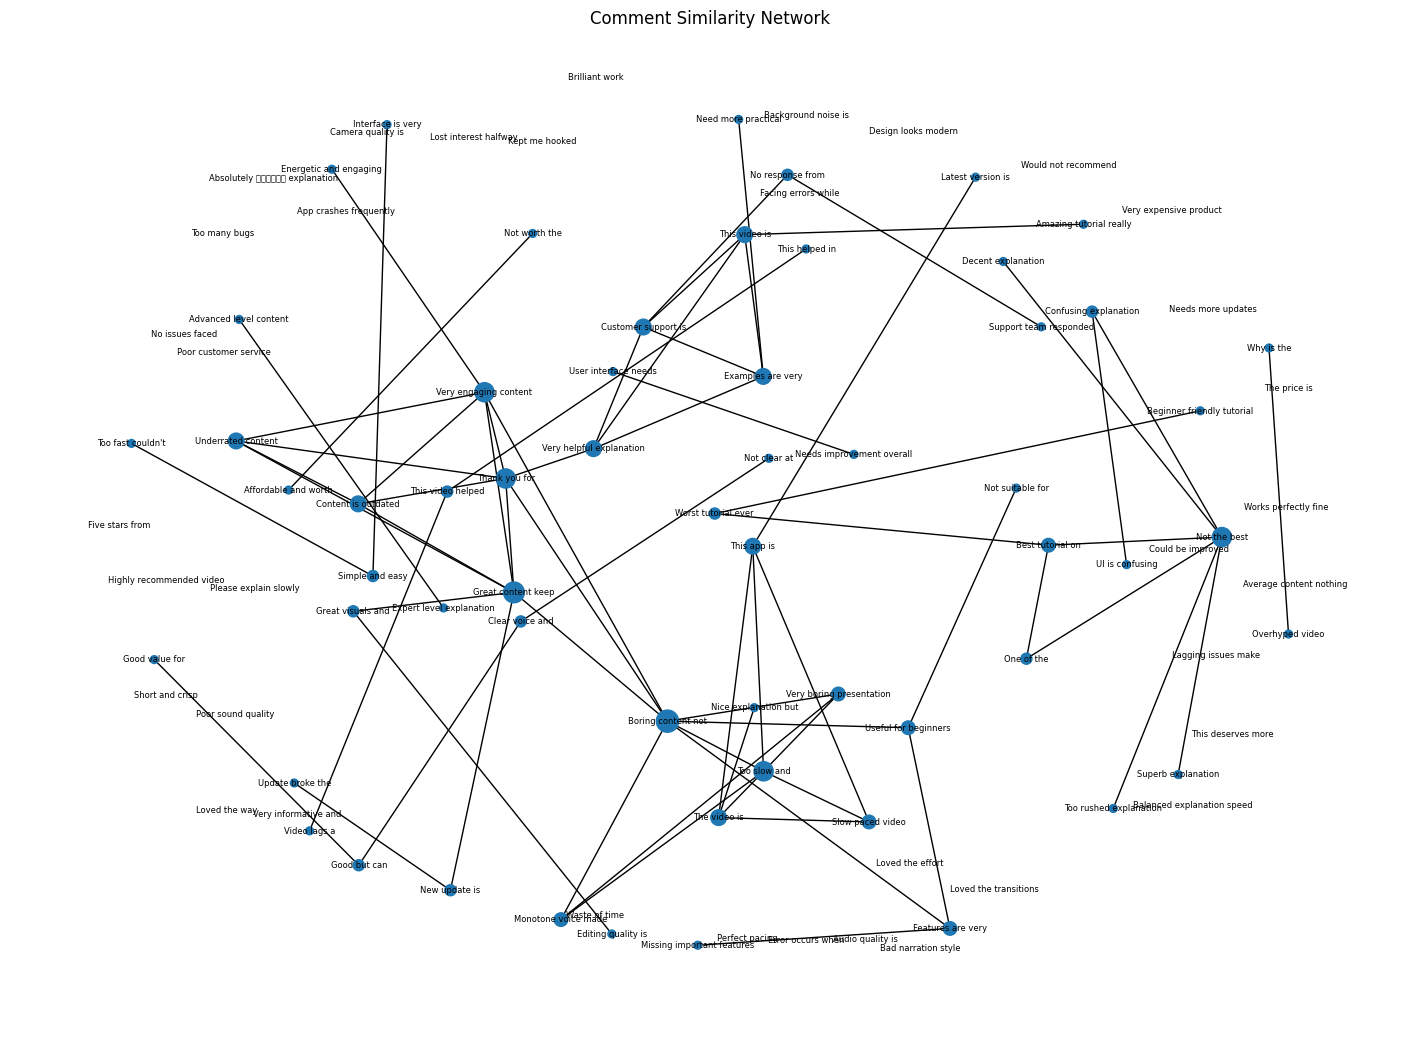


Top Influential Comments:
    Node    Degree  Betweenness  Closeness                  Label
8      8  0.085106     0.056738   0.140801     Boring content not
4      4  0.074468     0.026691   0.129385     Great content keep
6      6  0.063830     0.028598   0.112641           Too slow and
47    47  0.063830     0.006635   0.066285           Not the best
78    78  0.063830     0.008617   0.124344  Very engaging content


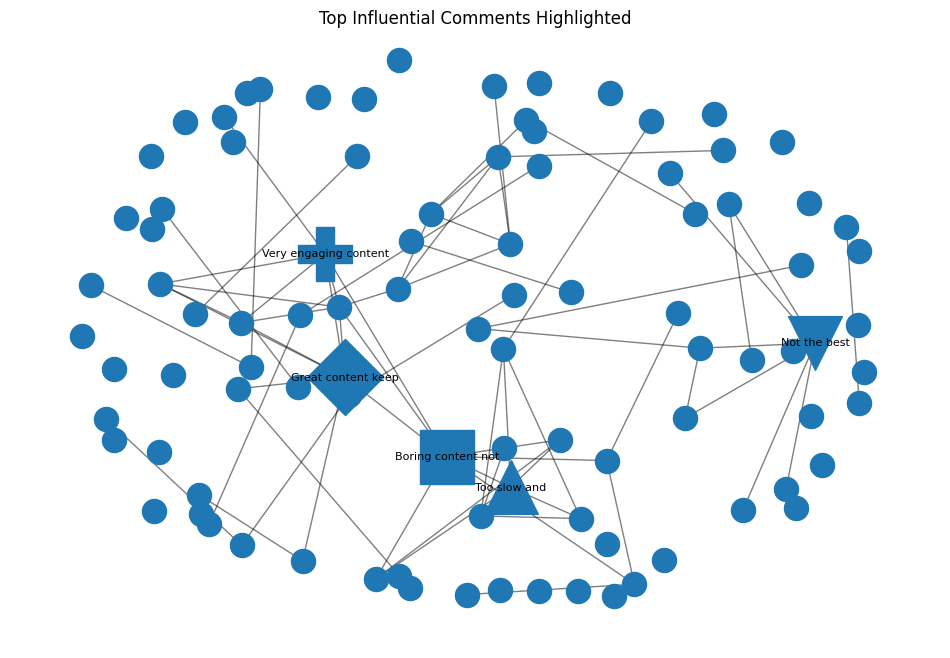

In [4]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# -------------------------------
# LOAD DATA
# -------------------------------
df = pd.read_csv('youtube_comments.csv')

# Ensure column exists
if 'Comment' not in df.columns:
    raise ValueError("CSV must contain 'Comment' column")

df = df.dropna(subset=['Comment'])
comments = df['Comment'].astype(str).tolist()

# -------------------------------
# TF-IDF + SIMILARITY
# -------------------------------
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(comments)
similarity_matrix = cosine_similarity(tfidf_matrix)

# -------------------------------
# CREATE GRAPH
# -------------------------------
G = nx.Graph()

labels = {}
for i, comment in enumerate(comments):
    short_label = " ".join(comment.split()[:3])
    labels[i] = short_label
    G.add_node(i, label=short_label)

# Add edges based on similarity
threshold = 0.3
for i in range(len(comments)):
    for j in range(i + 1, len(comments)):
        if similarity_matrix[i][j] > threshold:
            G.add_edge(i, j, weight=similarity_matrix[i][j])

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# -------------------------------
# CENTRALITY MEASURES
# -------------------------------
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)

centrality_df = pd.DataFrame({
    'Node': list(degree_centrality.keys()),
    'Degree': list(degree_centrality.values()),
    'Betweenness': list(betweenness_centrality.values()),
    'Closeness': list(closeness_centrality.values()),
})

# Add labels
centrality_df['Label'] = centrality_df['Node'].map(labels)

# -------------------------------
# BASIC VISUALIZATION
# -------------------------------
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.5, seed=42)

node_sizes = [v * 3000 for v in degree_centrality.values()]

nx.draw(
    G,
    pos,
    node_size=node_sizes,
    with_labels=False
)

nx.draw_networkx_labels(
    G,
    pos,
    labels=labels,
    font_size=6
)

plt.title("Comment Similarity Network")
plt.show()

# -------------------------------
# TOP INFLUENTIAL COMMENTS
# -------------------------------
print("\nTop Influential Comments:")
print(centrality_df.sort_values(by='Degree', ascending=False).head())

# -------------------------------
# HIGHLIGHT TOP 5 NODES
# -------------------------------
top5_nodes = centrality_df.sort_values(
    by='Degree', ascending=False
).head(5)['Node'].tolist()

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.5, seed=42)

# Normal nodes
normal_nodes = [n for n in G.nodes() if n not in top5_nodes]

nx.draw_networkx_nodes(
    G, pos,
    nodelist=normal_nodes,
    node_size=300,
    node_shape='o'
)

# Top nodes with different shapes
shapes = ['s', 'D', '^', 'v', 'P']

for i, node in enumerate(top5_nodes):
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=[node],
        node_size=1500,
        node_shape=shapes[i % len(shapes)]
    )

# Edges
nx.draw_networkx_edges(G, pos, alpha=0.5)

# Labels for top nodes only
top_labels = {node: labels[node] for node in top5_nodes}
nx.draw_networkx_labels(G, pos, labels=top_labels, font_size=8)

plt.title("Top Influential Comments Highlighted")
plt.axis('off')
plt.show()